# Air We Breathe: A Data Story on Air Quality in Allegheny County

# Introduction

This notebook presents an exploratory data analysis of air quality data collected in Allegheny County. The dataset, provided by the Allegheny County Health Department, includes measurements from monitoring stations across the region. The goal of this analysis is to understand patterns in air pollution levels over time and across different locations.

Through a series of visualizations, this notebook examines the distribution of pollution levels, trends over time, and differences between monitoring sites. These insights help highlight how air quality can vary and identify potential environmental concerns within the county.

It is important to note that the dataset is marked as unverified, meaning that some values may be subject to inaccuracies due to equipment or reporting issues. Despite this limitation, the analysis provides a useful overview of air quality patterns and serves as a foundation for further investigation.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

In [4]:
df = pd.read_csv("airqualitypitt.csv")

## Data Exploratory

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83439 entries, 0 to 83438
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   _id              83439 non-null  int64 
 1   date             83439 non-null  object
 2   site             83439 non-null  object
 3   parameter        83439 non-null  object
 4   index_value      83439 non-null  int64 
 5   description      83439 non-null  object
 6   health_advisory  7055 non-null   object
 7   health_effects   7055 non-null   object
dtypes: int64(2), object(6)
memory usage: 5.1+ MB


In [6]:
df.head()

,_id,date,site,parameter,index_value,description,health_advisory,health_effects
0,1,1/1/2016,Lawrenceville,PM25B,25,Good,NaN,NaN
1,2,1/1/2016,Flag Plaza,CO,0,Good,NaN,NaN
2,3,1/1/2016,Harrison Township,OZONE,31,Good,NaN,NaN
3,4,1/1/2016,Avalon,SO2,10,Good,NaN,NaN
4,5,1/1/2016,Lincoln,PM25,35,Good,NaN,NaN


In [7]:
df.columns

Index(['_id', 'date', 'site', 'parameter', 'index_value', 'description',
       'health_advisory', 'health_effects'],
      dtype='object')

In [8]:
df.describe()

,_id,index_value
count,83439.000000,83439.000000
mean,46201.354774,22.377593
std,29472.504473,19.107032
min,1.000000,0.000000
25%,20860.500000,6.000000
50%,41720.000000,19.000000
75%,73442.500000,34.000000
max,101632.000000,212.000000


In [10]:
df.isnull().sum()

_id                    0
date                   0
site                   0
parameter              0
index_value            0
description            0
health_advisory    76384
health_effects     76384
dtype: int64

In [12]:
df1 = df.drop(columns=['health_advisory', 'health_effects'])

In [20]:
df1['date'] = pd.to_datetime(df1['date'])

## Visual Data Story

The following visualization shows how air quality values are distributed across all observations.

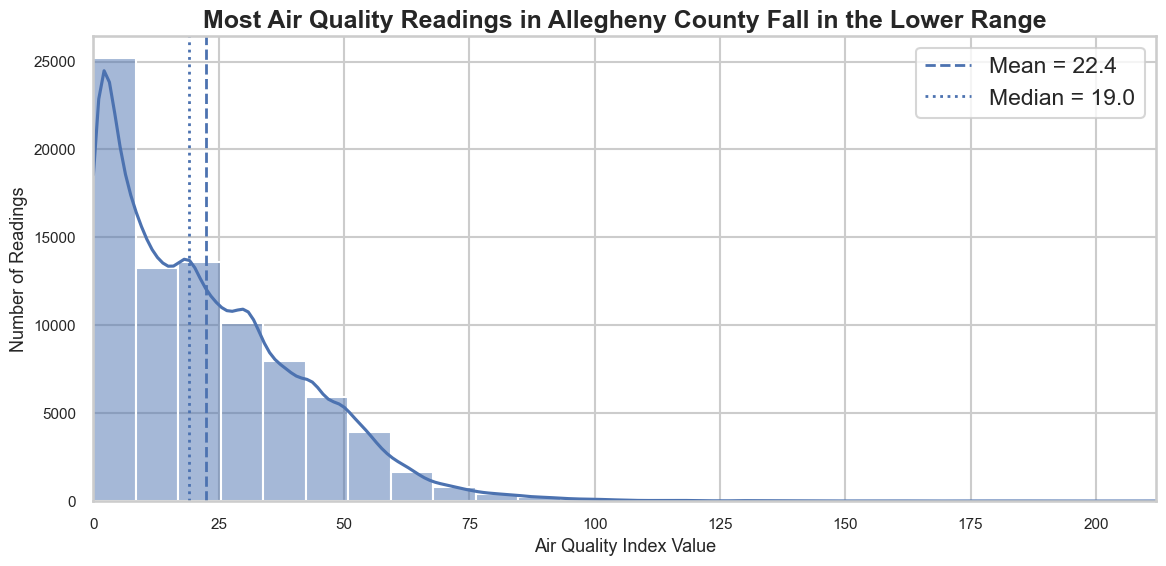

In [22]:
plt.figure(figsize=(12, 6))
sns.histplot(df1['index_value'], bins=25, kde=True)

plt.title("Most Air Quality Readings in Allegheny County Fall in the Lower Range")
plt.xlabel("Air Quality Index Value")
plt.ylabel("Number of Readings")
plt.xlim(0, df1['index_value'].max())

plt.axvline(df1['index_value'].mean(), linestyle='--', linewidth=2, label=f"Mean = {df1['index_value'].mean():.1f}")
plt.axvline(df1['index_value'].median(), linestyle=':', linewidth=2, label=f"Median = {df1['index_value'].median():.1f}")

plt.legend()
plt.tight_layout()
plt.show()

To better understand trends over time, the data was aggregated into monthly averages.

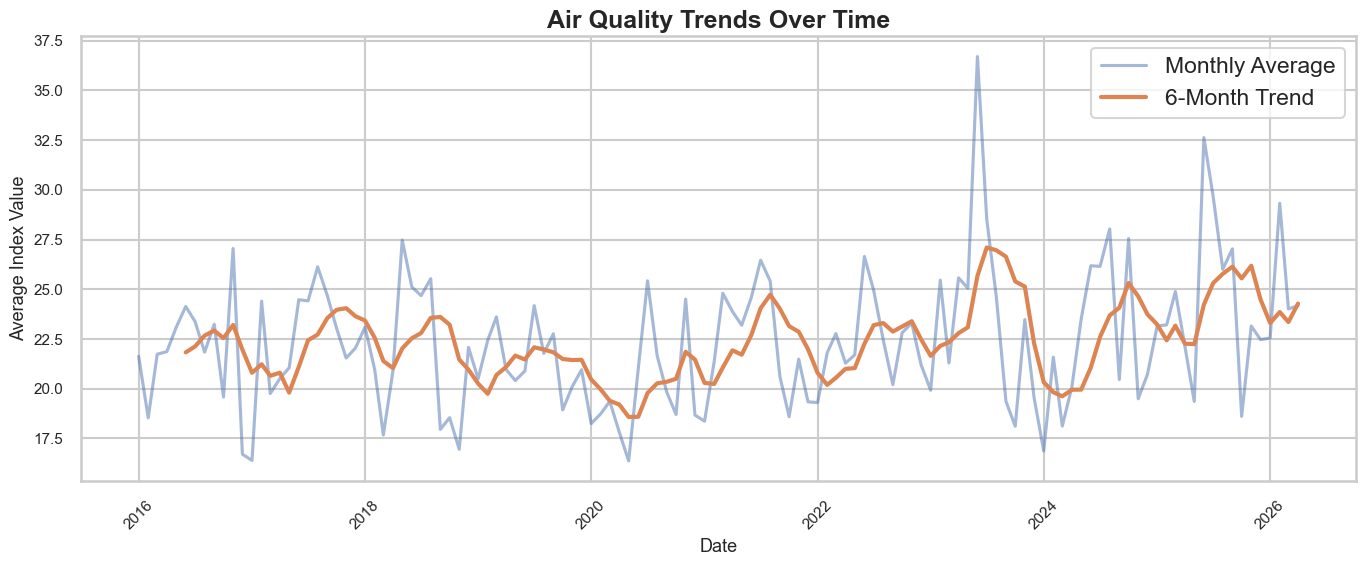

In [24]:
monthly_aqi['rolling_6mo'] = monthly_aqi['index_value'].rolling(6).mean()

plt.figure(figsize=(14, 6))
plt.plot(monthly_aqi['date'], monthly_aqi['index_value'], alpha=0.5, label='Monthly Average')
plt.plot(monthly_aqi['date'], monthly_aqi['rolling_6mo'], linewidth=3, label='6-Month Trend')

plt.title("Air Quality Trends Over Time")
plt.xlabel("Date")
plt.ylabel("Average Index Value")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

The following visualization shows how air quality index values are distributed across all observations.

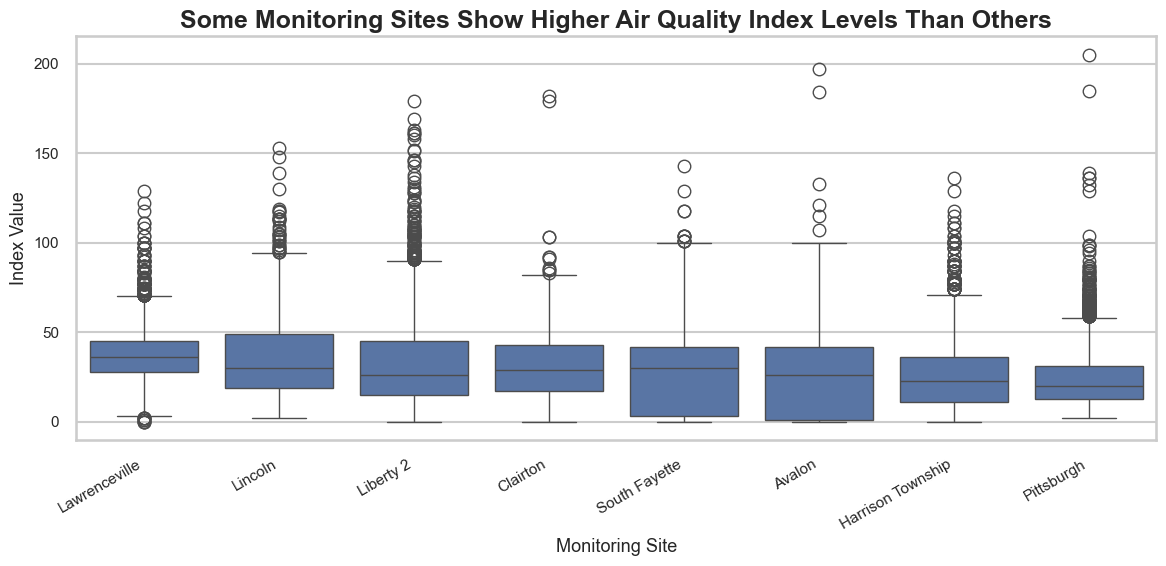

In [25]:
top_sites = (
    df1.groupby('site')['index_value']
    .mean()
    .sort_values(ascending=False)
    .head(8)
    .index
)

site_data = df1[df1['site'].isin(top_sites)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=site_data, x='site', y='index_value', order=top_sites)

plt.title("Some Monitoring Sites Show Higher Air Quality Index Levels Than Others")
plt.xlabel("Monitoring Site")
plt.ylabel("Index Value")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Narrative

Air quality is an important factor that directly affects public health, especially in urban and industrial regions such as Allegheny County. Using data collected from air quality monitoring stations, this analysis explores how pollution levels are distributed, how they change over time, and how they differ across locations. Although the dataset is marked as unverified, it still provides valuable insight into general air quality patterns.

The first visualization examines the distribution of air quality index values across all observations. The histogram shows that most readings fall within the lower range of the index, with a mean of approximately 22 and a median of 19. This indicates that air quality is generally moderate or acceptable for most of the recorded period. However, the distribution is right-skewed, meaning that there are occasional high values that represent spikes in pollution levels. These extreme values, which reach above 200 in some cases, suggest that while air quality is often stable, there are moments when it can become significantly worse.

The second visualization focuses on how air quality changes over time by analyzing the monthly average index values. Instead of plotting every individual observation, the data was aggregated to provide a clearer view of trends. The line chart shows fluctuations in air quality over the years, with periods of both improvement and decline. The addition of a six-month rolling average helps smooth out short-term variations and highlights the overall trend. While there is no dramatic long-term increase or decrease, the data suggests that air quality is not constant and varies depending on seasonal or environmental conditions.

The third visualization compares air quality levels across different monitoring sites. The boxplot reveals that some locations consistently experience higher index values than others, indicating variations in air quality across the county. These differences may be influenced by factors such as traffic density, industrial activity, or population concentration. Additionally, the presence of outliers suggests that certain areas are more prone to occasional spikes in pollution levels.

Overall, the analysis shows that air quality in Allegheny County is generally within a moderate range but is subject to variation over time and across locations. While most readings indicate acceptable conditions, the presence of occasional spikes highlights the importance of continued monitoring. These findings emphasize the need for awareness and potential actions to improve air quality and protect public health.

### Main Takeaway

Air quality in Allegheny County is generally moderate, but occasional spikes and differences across pollutant types highlight potential environmental and health concerns that require ongoing monitoring.